# Yulu Bike Sharing - EDA & Hypothesis Testing

***

## 1. Problem Statement
> **About Yulu:** <br>
> Yulu is India's leading micro-mobility service provider, offering electric bikes for daily urban commutes. Their mission is to reduce traffic congestion by providing a safe, affordable, and eco-friendly transportation alternative.

> **Business Problem:** <br>
> Yulu has observed a dip in revenue and wants to understand which factors significantly influence *<u>the demand for shared electric bikes</u>* in the Indian market. Identifying these factors will allow the company to better align supply with demand and make data-driven operational decisions.

> **Objectives:**
>
> 1. Explore the dataset to understand the distribution of demand across different conditions. 
> 2. Identify variables that significantly affect the number of bikes rented.
> 3. Use statistical hypothesis testing to confirm or reject assumptions about demand drivers. 
> 4. Provide actionable business recommendations.

> **Research Questions:**
>
> 1. Does working day vs. non-working day status affect rental demand? 
> 2. Does weather condition affect rental demand? 
> 3. Does season affect rental demand? 
> 4. Does the relationship between weather and season indicate statistical dependence that could affect demand modeling?

>**Significance Level:** <br>
$\alpha$ = 0.05, pre-registered before running any test to avoid *<u>p-hacking</u>* (*data dredging*). This means a <i><u>p-value</u></i> is required to be below 0.05 to reject any null hypothesis.
> * **Note on multiple comparisons:** Running 4 hypothesis tests under $\alpha$ = 0.05 means the family-wise error rate (probability of at least one false positive) is $1 - (0.95)^4 \approx 18.5%$. This is addressed explicitly in each post-hoc analysis using Bonferroni correction.


***

## 2. Dataset Description
> **Source:** Yulu Bike Sharing Dataset - [Kaggle](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data)

> **Format:** 1 CSV file; 10,886 rows x 12 columns


| Column | Type | Description |
| :---: | :---: | :---: |
| `datetime` | datetime | Hourly timestamp |
| `season` | categorical (1-4) | <b>1:</b> Spring, <b>2:</b> Summer, <br> <b>3:</b> Fall, <b>4:</b> Winter |
| `holiday` | binary | <b>1:</b> public holiday, <b>0:</b> not a holiday |
| `workingday` | binary | <b>1:</b> working day, <b>0:</b> weekend/holiday |
| `weather` | categorical (1-4) | <b>1:</b> Clear/Partly cloudy, <b>2:</b> Mist/Cloudy, <br> <b>3:</b> Light Snow/Rain, <b>4:</b> Heavy Rain/Thunderstorm |
| `temp` | continuous | Temperature in Celsius |
| `atemp` |  continuous | Feels like temperature in Celsius |
| `humidity` |  continuous | Relative humidity (%) |
| `windspeed` |  continuous | Wind speed |
| `casual` |  count | Count of casual (non-registered) users |
| `registered` |  count | Count of registered users |
| `count` |  <b>target</b> | *<u>Target variable</u>* - total rental count (casual + registered) | 


<div style="clear: both;"></div>

> **Prior expectations before seeing the data:**
>
> * `workingday` is expected to affect demand - casual and registered users may offset each other;
> * `weather` and `season` are expected to be the strongest drivers - extreme conditions intuitively suppress outdoor activity;
> * `temp` is expected to correlate positively with demand and `humidity` - negatively, as more comfortable weather conditions encourage outdoor mobility.

In [1]:
%%html
<style>
table{float:left}
</style>


***

## 3. Imports and Setup

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import shapiro, rankdata as rd, norm as sp_norm, levene, kruskal, chi2_contingency
from statsmodels.graphics.gofplots import qqplot
from itertools import combinations

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

ALPHA = 0.05


***

## 4. Load and Inspect Data

**First inspectation:** shape, null values, diplicates, data types. This step determines whether the dataset is ready for analysis or needs structural fixes before proceeding.

In [3]:
df = pd.read_csv('yulu_bike_sharing_dataset.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,1/1/2011 0:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,1/1/2011 1:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,1/1/2011 2:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,1/1/2011 3:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,1/1/2011 4:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
print(f'Shape: {df.shape}') # Number of rows and columns
print(f'\nNull values: \n{df.isna().sum()}') 
print(f'\nDuplicates: {df.duplicated().sum()}') 

Shape: (10886, 12)

Null values: 
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Duplicates: 0


In [5]:
df.info() # Description of the data (data type)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [6]:
df.describe().T # Description of the data (continuous data description)

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.506614,1.116174,1.00,2.0000,3.000,4.0000,4.0000
holiday,10886.0,0.028569,0.166599,0.00,0.0000,0.000,0.0000,1.0000
workingday,10886.0,0.680875,0.466159,0.00,0.0000,1.000,1.0000,1.0000
weather,10886.0,1.418427,0.633839,1.00,1.0000,1.000,2.0000,4.0000
temp,10886.0,20.230860,7.791590,0.82,13.9400,20.500,26.2400,41.0000
atemp,10886.0,23.655084,8.474601,0.76,16.6650,24.240,31.0600,45.4550
humidity,10886.0,61.886460,19.245033,0.00,47.0000,62.000,77.0000,100.0000
windspeed,10886.0,12.799395,8.164537,0.00,7.0015,12.998,16.9979,56.9969
casual,10886.0,36.021955,49.960477,0.00,4.0000,17.000,49.0000,367.0000
registered,10886.0,155.552177,151.039033,0.00,36.0000,118.000,222.0000,886.0000


>**Initial observations:**
> * 10,886 rows; 12 columns - no null values, no duplicates. Dataset is structurally clean;
> * Target variable `count` ranges from 1 to 977, mean $\approx$ 191. Strong right skew anticipated;
> * `casual` + `registered` = `count` exactly - no data leakage since as target is used only `count`;
> * `season` and `weather` are stored as integers but are inherently categorical - must be casted before any group-level analysis.


***

## 5. Data Preprocessing
>**Why this step matters for subsequent analysis?** <br>
>Raw integer codes for `season` (1-4) and `weather` (1-4) carry implicit ordinal meaning that could mislead statistical tests and visualizations. They need to be converted to labeled categories so that group comparisons are semantically correct. Temporal features are also extracted from `datetime` because time-of-day and month are expected demand drivers that would otherwise be buried in a single timestamp column. 

In [7]:
df['datetime'] = pd.to_datetime(df['datetime'])

df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.dayofweek

# Casting categoricals so seaborn/scipy does not treat them as numeric
cat_cols = ['season', 'holiday', 'workingday', 'weather']
for col in cat_cols:
    df[col] = df[col].astype('category')

# Makes plots and print statements easier to be read
df['season'] = df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
df['holiday'] = df['holiday'].map({0: 'No', 1: 'Yes'})
df['workingday'] = df['workingday'].map({0: 'No', 1: 'Yes'})
df['month'] = df['month'].map({1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
                               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'})

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,hour,day
0,2011-01-01 00:00:00,Spring,No,No,1,9.84,14.395,81,0.0,3,13,16,2011,Jan,0,5
1,2011-01-01 01:00:00,Spring,No,No,1,9.02,13.635,80,0.0,8,32,40,2011,Jan,1,5
2,2011-01-01 02:00:00,Spring,No,No,1,9.02,13.635,80,0.0,5,27,32,2011,Jan,2,5
3,2011-01-01 03:00:00,Spring,No,No,1,9.84,14.395,75,0.0,3,10,13,2011,Jan,3,5
4,2011-01-01 04:00:00,Spring,No,No,1,9.84,14.395,75,0.0,0,1,1,2011,Jan,4,5



***

## 6. Outlier Detection and Treatment
>**Interquartile Range method:**
>IQR method is used to flag outliers. A value is an outlier if it lies below $Q1 - 1.5 * IQR$ or above $Q3 + 1.5 * IQR$.

>**Winsorization (capping):**
>is applied as the treatment (what to be done with the outliers once found) rather than row removal for two reasons: <br>
> 1. The dataset is relatively small and dropping outlier rows would reduce statistical power;
> 2. Extreme rental counts are rare but real events. Capping preserves the observation while limiting distortion of distributional statistics.

>**Columns checked:**
>`windspeed`, `casual`, `registered`, `count`. The variables `temperature` and `humidity` are bounded by nature and do not require treatment.

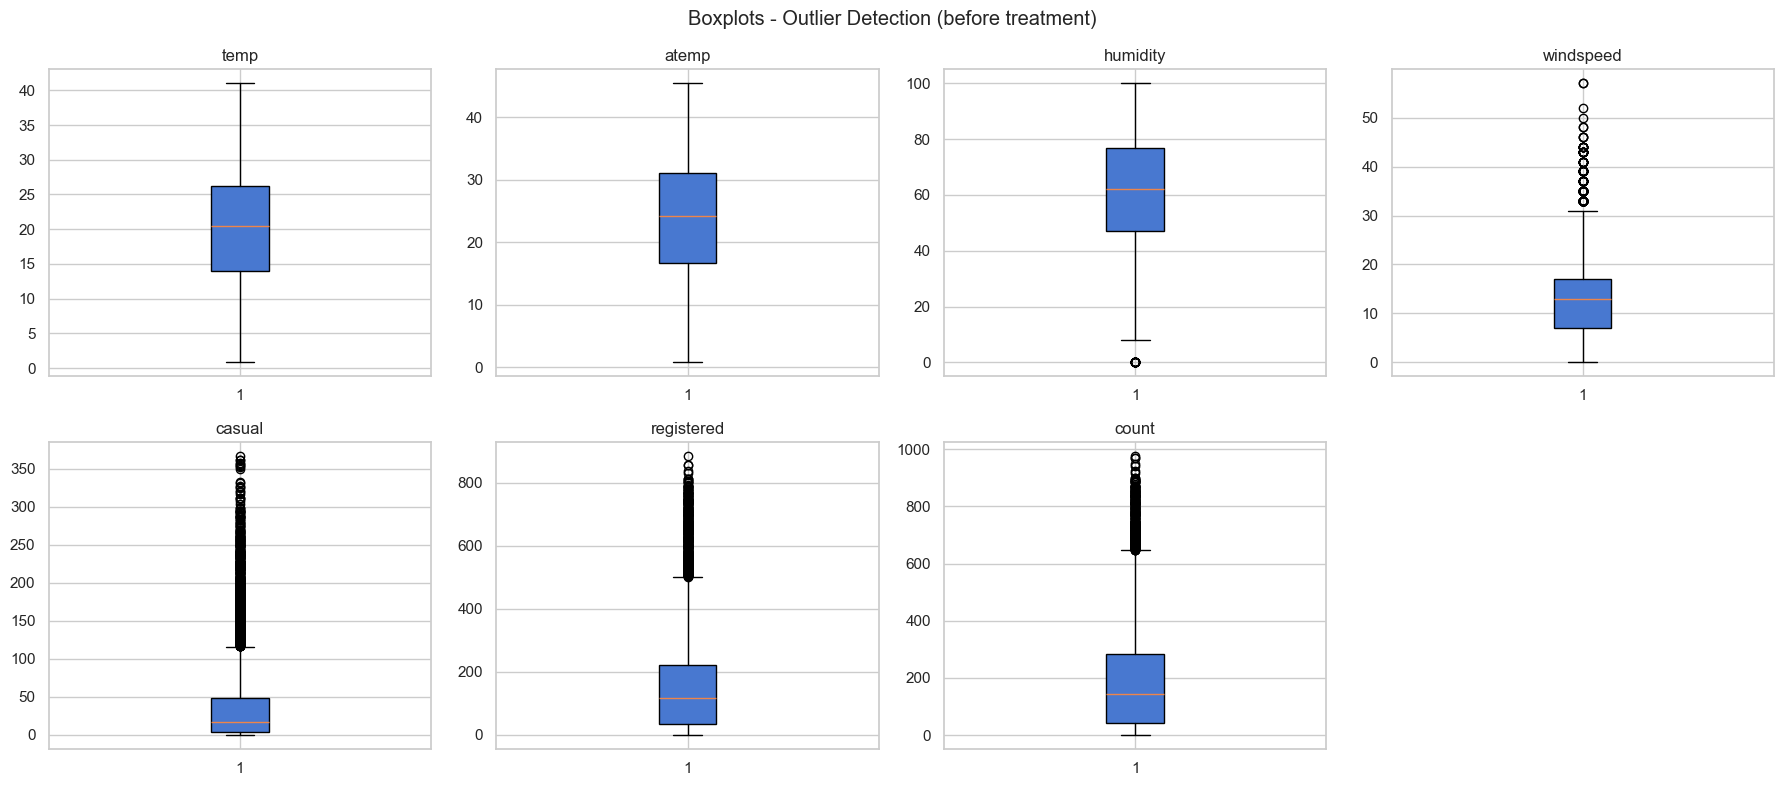

In [8]:
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten() # Converting 2D array of axes into a flat list for easier interpretation

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True)
    axes[i].set_title(col)

axes[-1].set_visible(False)

plt.suptitle('Boxplots - Outlier Detection (before treatment)')
plt.tight_layout()
plt.show()

Each box shows the interquartile range (Q1-Q3), with the horizontal line inside being the median. Individual points plotted beyond the whiskers are outliers by the IQR definition. <br>
The boxplots confirm that:
* `windspeed`, `casual`, `registered`, and `count` all have visible outliers - shown as dots above the upper ends;
* `temp`, `atemp`, and `humidity` show no extreme outliers, which is expected since these are physically bounded measurements.

In [9]:
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

print('IQR Outlier Bounds and Counts: ')
print(f"{'Column': <14} {'Lower': >10} {'Upper': >10} {'Outliers': >10} {'% of data': >12}") # '<14' means left-align field, 14 chars wide
print(' ' + '-' * 60)

for col in ['windspeed', 'casual', 'registered', 'count']:
    lower_bound, upper_bound = iqr_bounds(df[col])
    num_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum() # Boolean mask which counts values outside both fences
    print(f' {col: <14} {lower_bound: >10.2f} {upper_bound: >10.2f} {num_outliers: >10d} {num_outliers/len(df)*100: >11.1f}%')

IQR Outlier Bounds and Counts: 
Column              Lower      Upper   Outliers    % of data
 ------------------------------------------------------------
 windspeed           -7.99      31.99        227         2.1%
 casual             -63.50     116.50        749         6.9%
 registered        -243.00     501.00        423         3.9%
 count             -321.00     647.00        300         2.8%


* `casual` has the highest outlier rate at roughly 7% of observations, reflecting occasional spikes from events or holidays;
* `registered` has 3.9% outliers and `count` - 2.8%, both moderate, suggesting high-demand hours exist but are not frequent enough to dominate the dataset;
* `windspeed` has the fewest outliers at 2.1%, which are likely genuine high-wind events rather than data errors.

All 4 columns show only upper-tail outliers - there are no abnormally low values, which makes physical sense since rentals and wind speed cannot be negative.

In [10]:
df_clean = df.copy()

for col in ['windspeed', 'casual', 'registered', 'count']:
    lower_bound, upper_bound = iqr_bounds(df[col])
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound) # The clip function replaces any value that exceeds a bound with the bound value itself

print('Distribution comparison before vs. after Winsorization:\n')
print(f" {'Metric': <22} {'Before': >10} {'After': >10}")
print(' ' + '-' * 60)

stats_to_compare = [
    ('count mean', lambda s: s.mean()),
    ('count std', lambda s: s.std()),
    ('count median', lambda s: s.median()),
    ('count max', lambda s: s.max()),
]

for stat_name, func in stats_to_compare:
    print(f" {stat_name: <22} {func(df['count']): >10.2f} {func(df_clean['count']): >10.2f}")

print(f'\n Rows before: {len(df)} | Rows after: {len(df_clean)} (no rows dropped)')

Distribution comparison before vs. after Winsorization:

 Metric                     Before      After
 ------------------------------------------------------------
 count mean                 191.57     188.70
 count std                  181.14     172.42
 count median               145.00     145.00
 count max                  977.00     647.00

 Rows before: 10886 | Rows after: 10886 (no rows dropped)


Mean and median are almost unchanged after capping - confirming that the outliers were sparse extreme values, not a systematic data quality issue. <br>
The standard deviation decreases slightly, which is expected after capping the right tail.
* If rows were removed instead of capping, genuine high-demand observations would have been lost (such as popular holidays), which are arguably the most interesting data points for Yulu's operational planning.


***

## 7. Exploration Data Analysis (EDA)
> **Why EDA?** - EDA serves two purposes here: <br>
> 1. *Understand the data* - distributions, central tendencies, variance across groups;
> 2. *Inform test selection* - specifically, whether the target variable (`count`) follows a normal distribution, which determines whether parametric or non-parametric hypothesis tests are used. 

EDA is presented before hypothesis testing, not after, so that test selection is evidence-based rather than post-hoc rationalized.

### 7.1. Distribution of the Target Variable (`count`)

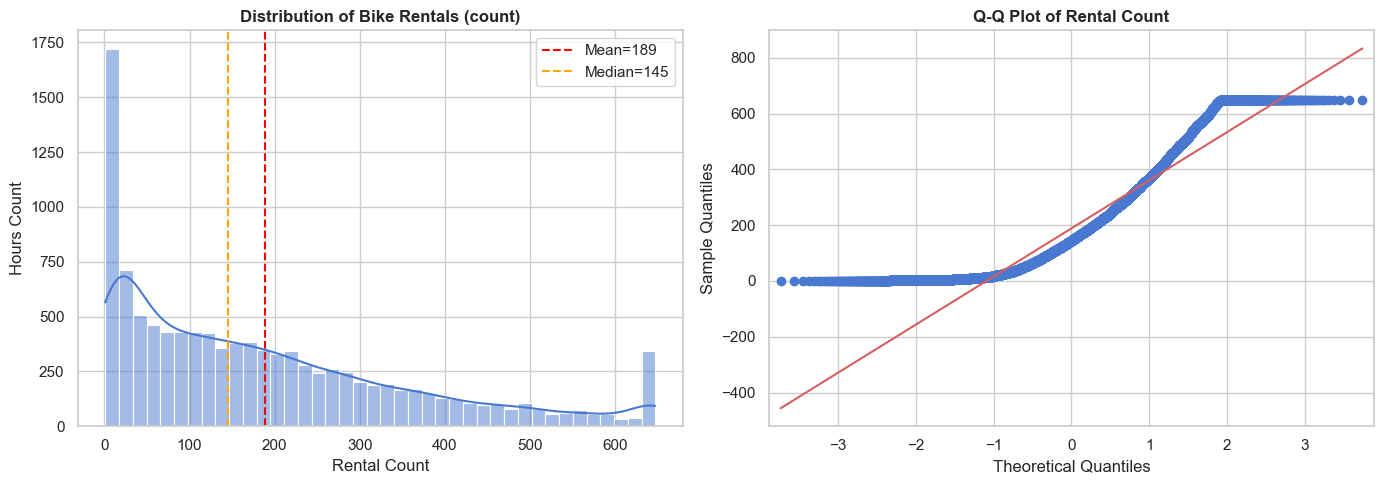

Shapiro-Wilk (n = 1000 sample): statistic = 0.8869, p = 2.1069e-26

p < α: reject normality assumption.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['count'], bins=40, kde=True, ax=ax1)
ax1.set_title('Distribution of Bike Rentals (count)', fontweight='bold')
ax1.set_xlabel('Rental Count')
ax1.set_ylabel('Hours Count')

# If mean > median the distribution is right-skewed
ax1.axvline(df_clean['count'].mean(), color='red', linestyle='--', label=f'Mean={df_clean['count'].mean():.0f}')
ax1.axvline(df_clean['count'].median(), color='orange', linestyle='--', label=f'Median={df_clean['count'].median():.0f}')
ax1.legend()

qqplot(df_clean['count'], line='s', ax=ax2) # line='s' fits a red reference line through the 25th and 75th percentiles of the data
ax2.set_title('Q-Q Plot of Rental Count', fontweight='bold')

plt.tight_layout()
plt.show()

statistic, p = shapiro(df_clean['count'].sample(1000, random_state=42))
print(f'Shapiro-Wilk (n = 1000 sample): statistic = {statistic:.4f}, p = {p:.4e}')
print()

if p < ALPHA:
    print('p < \u03B1: reject normality assumption.')
else:
    print('p >= \u03B1: fail to reject normality. Parametric tests may be appropriate.')

* **Histogram:** The histogram shows a right-skewed distribution - the majority of hourly observations cluster at low-to-moderate rental counts, with a long right tail representing rare high-demand hours.
* **Q-Q plot:** The Q-Q plot confirms the departure from normality: the points curve away from the reference line at both tails.
* **Normality Test:** The *Shapiro-Wilk* test formally confirms this (p < 0.05). This means parametric tests (t-test, ANOVA) that assume normality are not valid here, so non-parametric alternatives will be used throughout the hypothesis testing.
  
> **Note:** <br>
> *Shapiro-Wilk* is applied on a random subsample of 1000 observations. Because at very large `n`, the test detects trivially small deviations from normality that are statistically significant but practically irrelevant - subsampling keeps the test meaningful.

### 7.2 Categorical Variable Distributions

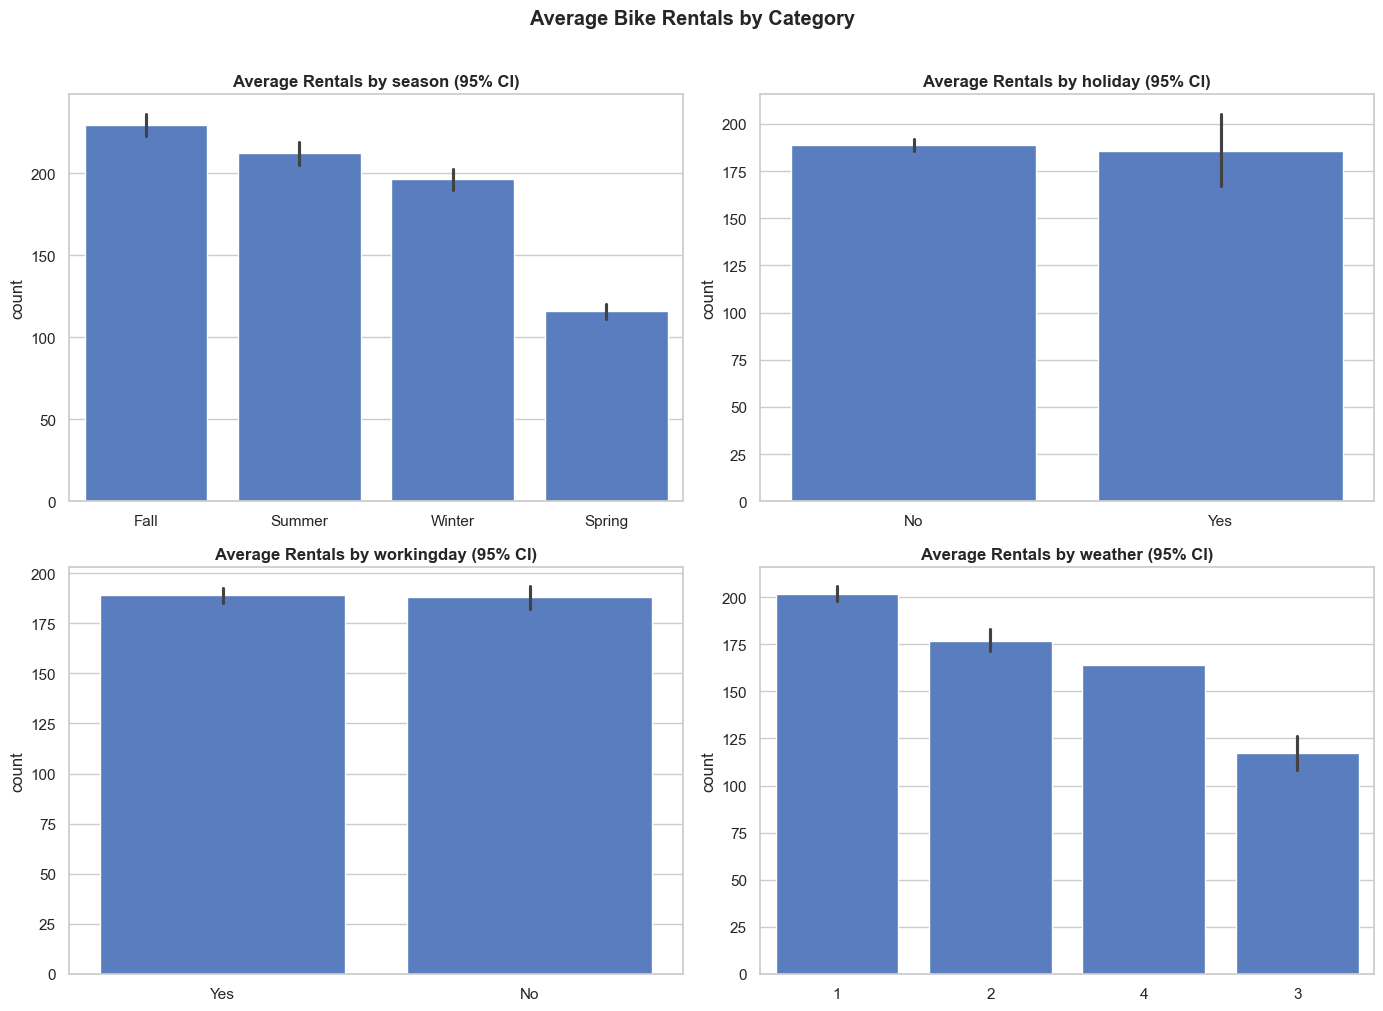

In [12]:
cat_plot_cols = ['season', 'holiday', 'workingday', 'weather']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    order = df_clean.groupby(col, observed=True)['count'].mean().sort_values(ascending=False).index
    sns.barplot(data=df_clean, x=col, y='count', order=order, ax=axes[i], errorbar=('ci', 95)) # The error bar shows 95% confidence interval around the mean
    axes[i].set_title(f'Average Rentals by {col} (95% CI)', fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Average Bike Rentals by Category', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

* **Season barchart:** Fall produces the highest average rentals, followed by Summer and Winter, while Spring shows substantially lower demand - roughly half of Fall's average rentals; 
* **Holiday barchart:** Holiday vs. Non-holiday days show nearly identical average rentals. The large overlap in confidence intervals (CI) suggests that holiday status alone is not a strong driver of demand;
* **Workingday barchart:** Working days vs. Non-working days also show minimal difference in average rentals, with almost identical bar heights and strongly overlapping CI. Though visually similar, this factor will be formally tested in Section 8, where the full distribution, not just the mean, is taken into account; 
* **Weather barchart:** Weather shows a clear negative effect on rentals: clear conditions (category 1) have the highest rentals, followed by mist/cloudy conditions (category 2). Rentals drop further during heavy rain (category 4) and light rain/snow conditions (category 3). The chart shows category 4 before category 3 because the bars are ordered by mean rental value, however, category 4 contains very few observations, making its average statistically unstable. 
> **Note:** Weather category 4 has extremely few observations. With such a small sample size, *seaborn* cannot reliably estimate the bootstrap CI, so the error bar is not displayed. 

### 7.3 Temporal Patterns

Understanding hourly and monthly patterns is critical for operational planning because it informs Yulu *when* to have bikes available, not just *how many*.

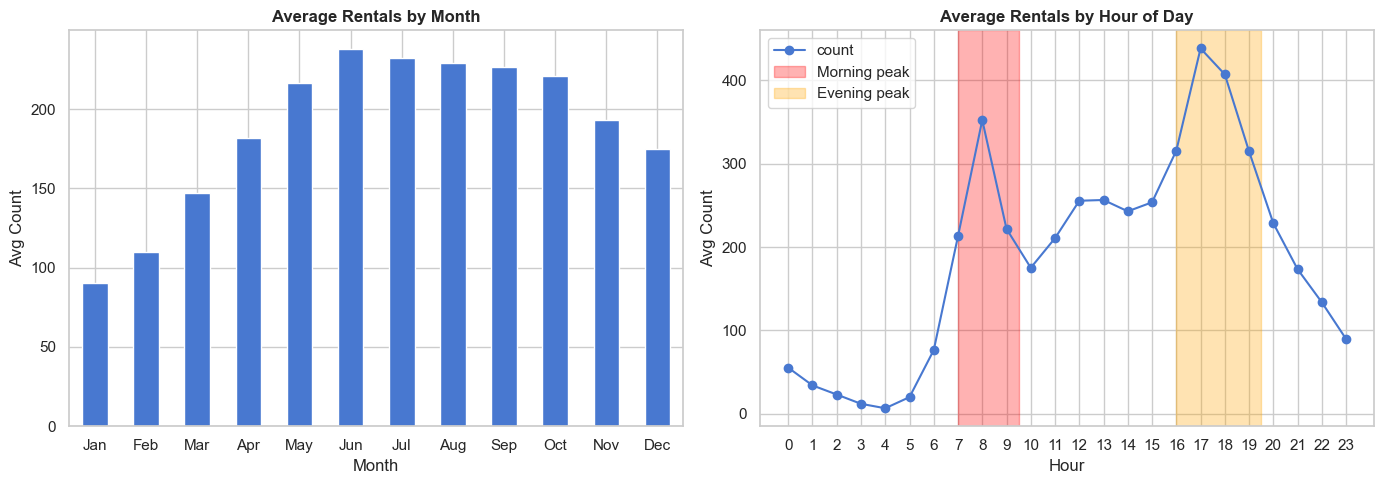

Peak hours (top 5 by average rentals):
hour
17    438.500000
18    407.289474
8     352.472527
16    315.800439
19    314.756579


In [13]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly = df_clean.groupby('month')['count'].mean().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Rentals by Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Count')
axes[0].tick_params(axis='x', rotation=360)

hourly = df_clean.groupby('hour')['count'].mean()
hourly.plot(kind='line', ax=axes[1], marker='o')
axes[1].set_xticks(range(0, 24))
axes[1].set_title('Average Rentals by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Avg Count')
axes[1].axvspan(7, 9.5, alpha=0.3, color='red', label='Morning peak') # This puts a light red shade over morning commute hours
axes[1].axvspan(16, 19.5, alpha=0.3, color='orange', label='Evening peak') # This puts a light orange shade over evening commute hours
axes[1].legend()

plt.tight_layout()
plt.show()

print('Peak hours (top 5 by average rentals):')
print(hourly.nlargest(5).to_string())

* **Month plot:** Monthly rentals peak between May and October, aligning with warmer temperatures. With June being the highest and January and February - the lowest;
* **Hour plot:** The hourly pattern shows two clear spikes: 8am and 17:00-18:00, which are classic commuter peaks. This strongly suggests registered users are primarily using Yulu for work commutes rather than leisure.

### 7.4 Casual vs. Registered Users

Analyzing rentals by user type helps identify distinct behavioral patterns between casual and registered riders, which can inform targeted operational strategies and demand management.

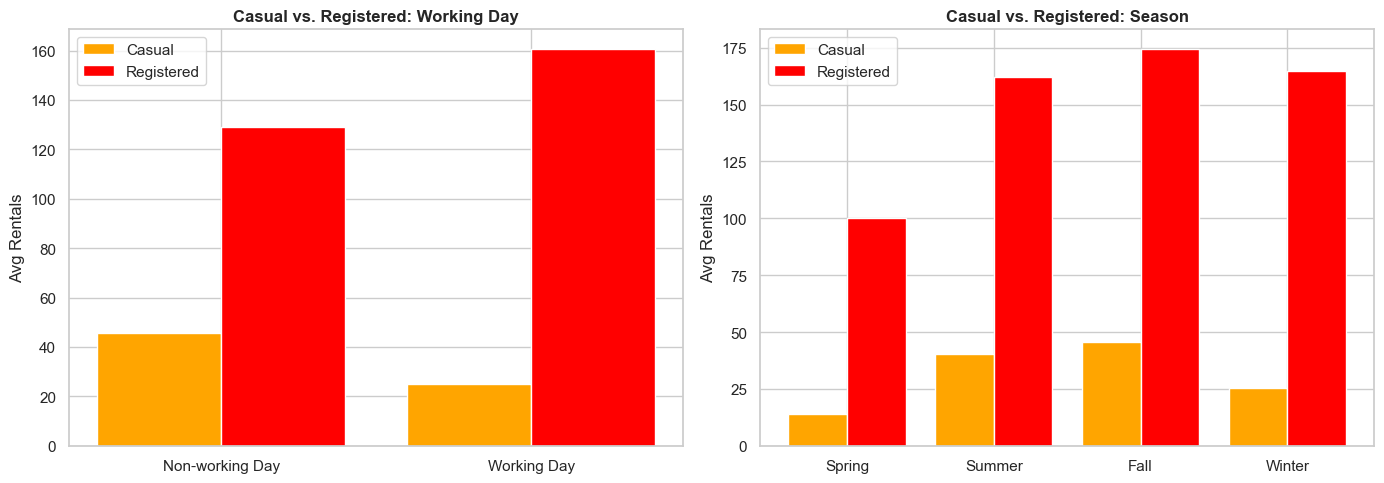

Key observations (working day):
  - Casual -> non-working: 45.6 vs. working: 24.9
  - Registered -> non-working: 129.1 vs. working: 160.5


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

workingday_groups = ['No', 'Yes']
x = np.arange(len(workingday_groups)) # [0, 1] -> numeric positions for the bars on the x-axis
casual_means = [df_clean[df_clean['workingday']==g]['casual'].mean() for g in workingday_groups]
registered_means = [df_clean[df_clean['workingday']==g]['registered'].mean() for g in workingday_groups]

# 'x-2' and 'x+2' shift the 2 bars left(-0.2)/right(+0.2) so they do not overlap
axes[0].bar(x - 0.2, casual_means, 0.4, label='Casual', color='orange') # '0.4' is the bar width
axes[0].bar(x + 0.2, registered_means, 0.4, label='Registered', color='red')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Non-working Day', 'Working Day'])
axes[0].set_title('Casual vs. Registered: Working Day', fontweight='bold')
axes[0].set_ylabel('Avg Rentals')
axes[0].legend()

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
x2 = np.arange(4)
casual_2 = [df_clean[df_clean['season']==s]['casual'].mean() for s in season_order]
registered_2 = [df_clean[df_clean['season']==s]['registered'].mean() for s in season_order]

axes[1].bar(x2 - 0.2, casual_2, 0.4, label='Casual', color='orange')
axes[1].bar(x2 + 0.2, registered_2, 0.4, label='Registered', color='red')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(season_order)
axes[1].set_title('Casual vs. Registered: Season', fontweight='bold')
axes[1].set_ylabel('Avg Rentals')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Key observations (working day):')
print(f'  - Casual -> non-working: {casual_means[0]:.1f} vs. working: {casual_means[1]:.1f}')
print(f'  - Registered -> non-working: {registered_means[0]:.1f} vs. working: {registered_means[1]:.1f}')

Registered users average roughly 2-4 times more rentals than casual users across all conditions, confirming that they form the primary demand base of the bike-sharing system.
* **Working day barchart:** On working days, registered rentals increase noticeably while casual rentals drop. The opposite pattern occurs on non-working days, where casual usage rises and registered usage falls. This crossover strongly suggests that <u>two distinct use cases coexist on the platform</u>: registered users primarily rely om the service for weekday commuting, whereas casual users tend to ride for leisure;
* **Season barchart:** Seasonally, Fall records the highest rental averages for both user groups, while Spring shows the lowest demand. Rentals remain relatively strong in Summer and Winter, particularly among registered users, suggesting that regular riders continue using the service even in colder conditions. Casual usage, however, appears more sensitive to seasonal changes, increasing mainly during warmer periods.

### 7.5 Correlation Analysis

Both - Pearson (linear) and Spearman (rank/monotonic) correlations, are computed. Agreement between them indicates that relationships are monotonic, which matters for the choice of non-parametric tests.

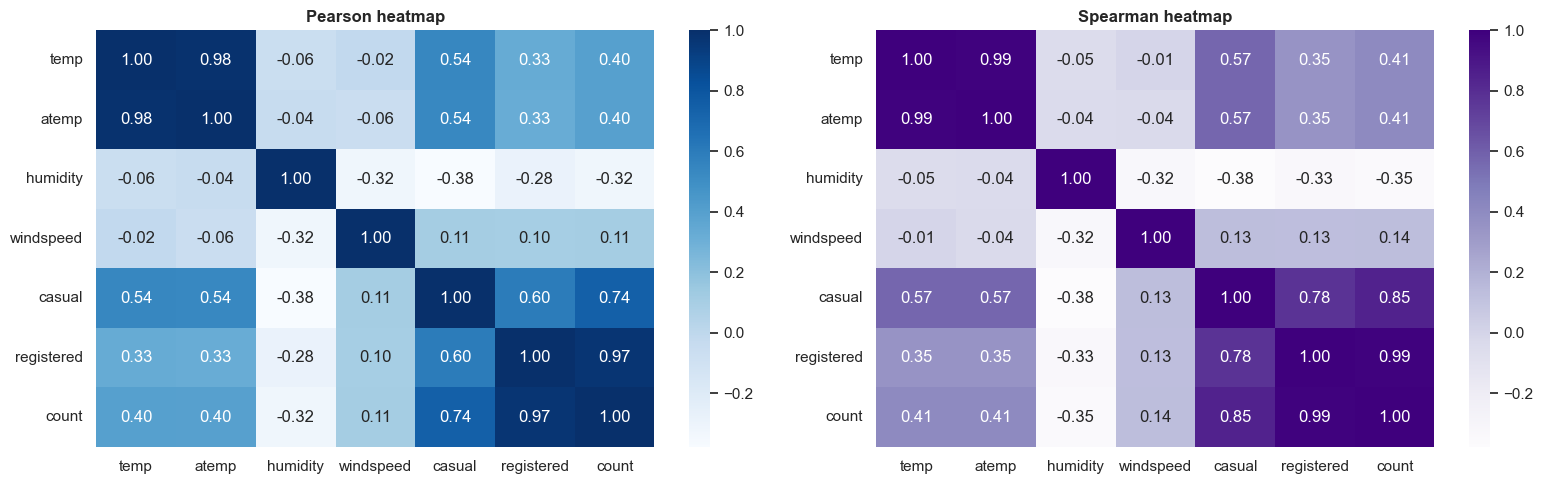

count ~ temperature: Pearson r = 0.40, Spearman ρ = 0.41
count ~ humidity: Pearson r = -0.32, Spearman ρ = -0.35
count ~ windspeed: Pearson r = 0.11, Spearman ρ = 0.14


In [15]:
correlation_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df_clean[correlation_cols].corr(method='pearson'), annot=True, fmt='.2f', cmap='Blues', ax=ax1)
ax1.set_title('Pearson heatmap', fontweight='bold')
ax1.tick_params(axis='x', rotation=360)
ax1.tick_params(axis='y', rotation=360)

sns.heatmap(df_clean[correlation_cols].corr(method='spearman'), annot=True, fmt='.2f', cmap='Purples', ax=ax2)
ax2.set_title('Spearman heatmap', fontweight='bold')
ax2.tick_params(axis='x', rotation=360)
ax2.tick_params(axis='y', rotation=360)

plt.tight_layout()
plt.show()

pearson_temp = df_clean['count'].corr(df_clean['temp'], method='pearson')
spearman_temp = df_clean['count'].corr(df_clean['temp'], method='spearman')

pearson_hum = df_clean['count'].corr(df_clean['humidity'], method='pearson')
spearman_hum = df_clean['count'].corr(df_clean['humidity'], method='spearman')

pearson_wind = df_clean['count'].corr(df_clean['windspeed'], method='pearson')
spearman_wind = df_clean['count'].corr(df_clean['windspeed'], method='spearman')

print(f'count ~ temperature: Pearson r = {pearson_temp:.2f}, Spearman \u03C1 = {spearman_temp:.2f}')
print(f'count ~ humidity: Pearson r = {pearson_hum:.2f}, Spearman \u03C1 = {spearman_hum:.2f}')
print(f'count ~ windspeed: Pearson r = {pearson_wind:.2f}, Spearman \u03C1 = {spearman_wind:.2f}')

Both *Pearson* and *Spearman* agree that:
* `temp` and `atemp` are strongly positively correlated with `count` - warmer weather drives more rentals;
* `humidity` shows a moderate negative relationship - high humidity reduces riding comfort, suppressing demand;
* `windspeed` has a weak negative correlation.

The high correlation between `temp` and `atemp` (r > 0.98) means these two columns are nearly redundant, using both in any future regression model would introduce multicollinearity.


***

## 8. Hypothesis Testing

### Mathematical Framework

The EDA in *Section 7* established that `count` is <u>not normally distributed</u> (right-skewed, Shapiro-Wilk p < 0.001). The table below shows the full decision framework for reference. Since normality fails in the present analysis, the Kruskal-Wallis row applies to Tests 1-3. Test 4 uses Chi-Square independently, as it deals with two categorical variables rather than a numeric outcome.

| Condition | Test for 2 groups | Test for 3+ groups |
| :---: | :---: | :---: |
| Normal + Equal variances | Independent t-test | One-way ANOVA |
| Normal + Unequal variances | Welch's t-test | Welch's ANOVA |
| Non-normal (this case) | Kruskal-Wallis | Kruskal-Wallis |
| Categorical + Categorical | Chi-Square | Chi-Square |


<div style="clear: both;"></div>

**Standard testing protocol applied to all hypotheses:** <br>
&nbsp;&nbsp; 1. **Normality check** - Shapiro-Wilk on each group. $H_0$: data is normally distributed; <br>
&nbsp;&nbsp; 2. **Variance homogeneity** - Levene's test. $H_0$: all group variances are equal; <br>
&nbsp;&nbsp; 3. **Main test** - Kruskal-Wallis for all group comparisons (Tests 1-3), Chi-Square for categorical independence (Test 4); <br>
&nbsp;&nbsp; 4. **Effect size** - $\eta ^ 2$ for Kruskal-Wallis, Cramer's V for Chi-Square; <br>
&nbsp;&nbsp; 5. **Post-hoc pairwise comparisons** (where 3+ groups exist) - Dunn's test with Bonferroni correction to identify which specific groups differ.

**Effect size interpretation ($\eta ^ 2$):**
* < 0.01 -> negligible;
* 0.01 - 0.06 -> small;
* 0.06 - 0.14 -> medium;
* $\geq$ 0.14 -> large

**Why post-hoc matters?** - Kruskal-Wallis only tells <u>that at least one group differs</u>, but Dunn's test tells <u>which pairs differ</u>. Without it specific recommendations can't be made (for example: "Summer vs. Spring" requires pairwise knowledge).

**Dunn's test implementation:** Implemented manually using rank-based z-scores with Bonferroni correction, since *scipy* does not provide a native implementation.

In [16]:
# Compute eta-square effect size for Kruskal-Wallis test
def kruskal_eta_squared(h_statistic, n_total, k_groups):
    formula = (h_statistic - k_groups + 1) / (n_total - k_groups)
    return formula

# Compute Cramer's V effect size for Chi-Square test; range is [0-1]
def cramers_v(chi2_statistic, n, rows_num, cols_num):
    formula = np.sqrt(chi2_statistic / (n * (min(rows_num, cols_num) - 1)))
    return formula

def effect_label(eta2):
    if eta2 < 0.01:
        return 'negligible'
    elif eta2 < 0.06:
        return 'small'
    elif eta2 < 0.14:
        return 'medium'
    else:
        return 'large'

def dunns_test_manual(groups, group_names, alpha = ALPHA):
    all_data = np.concatenate([np.asarray(g) for g in groups])
    all_ranks = rd(all_data)
    n_total = len(all_data)

    start = 0
    group_ranks, group_sample_sizes = [], []
    
    for g in groups:
        group_size = len(g)
        group_ranks.append(all_ranks[start: start + group_size])
        group_sample_sizes.append(group_size)
        start += group_size

    mean_ranks = [r.mean() for r in group_ranks]

    _, counts = np.unique(all_ranks, return_counts=True) # '_' ignores the unique values, keeping only their occurrence counts
    tie_correction = np.sum(counts**3 - counts) / (12 * (n_total - 1)) # Reduces the variance estimate when multiple observations share the same rank

    # Total number of pairwise comparisons, used for Bonferroni correction
    num_comparisons = len(list(combinations(range(len(groups)), 2)))

    results = []
    for i, j in combinations(range(len(groups)), 2):
        i_size, j_size = group_sample_sizes[i], group_sample_sizes[j]
        variance = (n_total * (n_total + 1) / 12 - tie_correction) * (1 / i_size + 1 / j_size)
        se = np.sqrt(variance)
        z = (mean_ranks[i] - mean_ranks[j]) / se
        p_raw = 2 * (1 - sp_norm.cdf(abs(z)))
        p_bonf = min(p_raw * num_comparisons, 1.0)

        results.append({
            'Group A': f'{group_names[i]: <7}',
            'Group B': f'{group_names[j]: >5}',
            'Mean Rank A': round(mean_ranks[i], 1),
            'Mean Rank B': round(mean_ranks[j], 1),
            'Z-statistic': round(z, 3),
            'p-value (raw)': f'{p_raw:.4e}', # round(p_raw, 4)
            'p-value (Bonferroni)': f'{p_bonf:.4e}', # round(p_bonf, 4)
            'Significant?': 'Yes' if p_bonf < alpha else 'No'
        })

    return pd.DataFrame(results)


***

### Test 1 - Does Working Day affect bike rental demand?

**Prior belief:** <br>
Registered (commuter) users are expected to generate higher demand on working days, while casual users may contribute more to rentals on non-working days. Because total rentals (`count`) combine both user groups, these opposing patterns may offset each other, making the overall impact of working day status on total demand uncertain. This motivates formal statistical testing. <br>

**$H_0$:** The distribution of bike rentals is the same on working and non-working days. <br>
**$H_1$:** The distribution of bike rentals differs between working and non-working days.

**Significance level: $\alpha = 0.05$**

In [17]:
working = df_clean[df_clean['workingday'] == 'Yes']['count']
non_working = df_clean[df_clean['workingday'] == 'No']['count']

print(f'Group sizes -> working = {len(working)}, non-working = {len(non_working)}')
print(f'Medians: working = {working.median():.1f}, non-working = {non_working.median():.1f}')
print()

print('Step 1 -> Normality check (Shapiro-Wilk, n = 1000 sample):')
_, p_working = shapiro(working.sample(min(1000, len(working)), random_state=42))
_, p_non_working = shapiro(non_working.sample(min(1000, len(non_working)), random_state=42))
print(f" - working: p = {p_working:.4e} => {'Not normal' if p_working < ALPHA else 'Normal'}")
print(f" - non-working: p = {p_non_working:.4e} => {'Not normal' if p_non_working < ALPHA else 'Normal'}")
print()

print("Step 2 -> Variance homogeneity (Levene's test):")
lev_statistic, p_lev = levene(working, non_working)
print(f' - Levene: statistic = {lev_statistic:.4f}, p = {p_lev:.4f}')
print(f" - Variances {'Not' if p_lev < ALPHA else ''}equal")
print()

print('Step 3 -> Kruskal-Wallis test:')
kw_statistic, p_kw = kruskal(working, non_working)
print(f' - H = {kw_statistic:.4f}, p = {p_kw:.4f}')
print()

print('Step 4 -> Effect size:', end='')
eta2 = kruskal_eta_squared(kw_statistic, len(working) + len(non_working), 2)
e_label = effect_label(eta2)
print(f' \u03B7\u00B2 = {eta2:.4f} ({e_label})')
print()

print('--- Results ---')
if p_kw < ALPHA:
    print(f' - p = {p_kw:.4f} < \u03B1 = {ALPHA} -> REJECTS H\u2080')
else:
    print(f' - p = {p_kw:.4f} >= \u03B1 = {ALPHA} -> FAILS TO REJECT H\u2080')

Group sizes -> working = 7412, non-working = 3474
Medians: working = 151.0, non-working = 128.0

Step 1 -> Normality check (Shapiro-Wilk, n = 1000 sample):
 - working: p = 2.1950e-26 => Not normal
 - non-working: p = 4.3825e-27 => Not normal

Step 2 -> Variance homogeneity (Levene's test):
 - Levene: statistic = 2.2064, p = 0.1375
 - Variances equal

Step 3 -> Kruskal-Wallis test:
 - H = 0.0045, p = 0.9467

Step 4 -> Effect size: η² = -0.0001 (negligible)

--- Results ---
 - p = 0.9467 >= α = 0.05 -> FAILS TO REJECT H₀


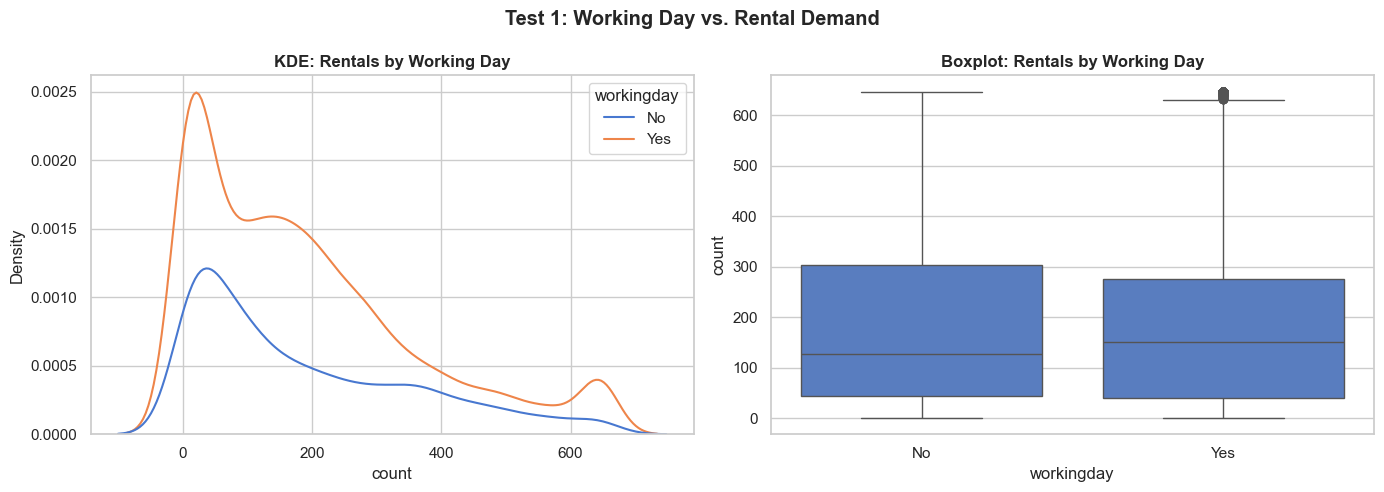

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.kdeplot(data=df_clean, x='count', hue='workingday', ax=axes[0])
axes[0].set_title('KDE: Rentals by Working Day', fontweight='bold')

sns.boxplot(data=df_clean, x='workingday', y='count', ax=axes[1])
axes[1].set_title('Boxplot: Rentals by Working Day', fontweight='bold')

plt.suptitle('Test 1: Working Day vs. Rental Demand', fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretation:** <br>
> -> The Kruskal-Wallis test found <u>no statistically significant difference</u> in total bike rental demand between working and non-working days ($p = 0.9467 \geq \alpha = 0.05$). Therefore, the null hypothesis ($H_0$) that rental distributions are the same across working and non-working days cannot be rejected. The estimated effect size ($\eta ^ 2 \approx 0$) indicates a <u>negligible</u> practical impact of working day status on overall rental demand. <br>
> -> The KDE (Kernel Density Estimation) curves and boxplots support this result. The distributions of rentals for working and non-working days overlap strongly, and their medians and interquartile ranges are very similar. Although the median rental count is slightly higher on working days, the difference is small relative to the overall variability in demand. <br>
> -> As observed earlier in *Section 7.4*, the composition of users differs across day types - registered (commuter) users tend to dominate working days, while casual users contribute relatively more on non-working days. These shifts in user behavior appear to balance each other, resulting in a similar total number of rentals across day types.


***

### Test 2 - Does Weather Condition affect bike rental demand?

**Prior belief:** <br>
Wheather conditions are expected to strongly influence bike rental demand. Favorable weather (clear or partly cloudy conditions) should encourage cycling and lead to higher rental counts, while adverse weather (rain, snow or storms) is likely to discourage bike usage due to discomfort and safety concerns. As weather condition worsen, the number of rentals is expected to decrease. However, the magnitude of this effect and whether rental distribution differ significantly between specific weather categories requires formal statistical testing. <br>

$H_0$: The distribution of bike rentals is the same across all weather conditions. <br>
$H_1$: At least one weather condition has a different distribution of bike rentals.

**Significance level: $\alpha = 0.05$**

In [19]:
# weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light rain/snow', 4: 'Heavy rain'}
"""
Weather category 4 contains only one observation in the dataset. Because statistical tests require sufficient
sample sizes within each group, this category was excluded from the hypothesis testing procedure.
"""

weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light rain/snow'}
df_clean['weather_label'] = df_clean['weather'].map(weather_map)

weather_groups, weather_labels = [], []
for w, label in weather_map.items():
    group = df_clean[df_clean['weather'] == w]['count']

    if len(group) > 0:
        weather_groups.append(group)
        weather_labels.append(label)
        print(f'{label: <15} -> n = {len(group): <5}, median = {group.median():.2f}, mean = {group.mean():.2f}')
print()

print('Step 1 -> Normality check (Shapiro-Wilk per group):')
for label, group in zip(weather_labels, weather_groups):
    _, p = shapiro(group.sample(min(500, len(group)), random_state=42))    
    print(f" - {label: <15}: p = {p:.4e} => {'Not normal' if p < ALPHA else 'Normal'}")
print()

print("Step 2 -> Variance homogeneity (Levene's test):")
lev_statistic, p_lev = levene(*weather_groups) # '*' unpacks the list so each weather group is passed as a separate argument
print(f' - Levene: statistic = {lev_statistic:.4f}, p = {p_lev:.4e}')
print(f" - Variances {'Not' if p_lev < ALPHA else ''} equal")
print()

print('Step 3 -> Kruskal-Wallis test:')
kw_statistic, p_kw = kruskal(*weather_groups)
print(f' - H = {kw_statistic:.4f}, p = {p_kw:.4e}')
print()

print('Step 4 -> Effect size:', end='')
n_total = sum(len(g) for g in weather_groups)
eta2 = kruskal_eta_squared(kw_statistic, n_total, len(weather_groups))
e_label = effect_label(eta2)
print(f' \u03B7\u00B2 = {eta2:.4f} ({e_label})')
print()

print('--- Results ---')
if p_kw < ALPHA:
    print(f' - p = {p_kw:.4e} < \u03B1 = {ALPHA} -> REJECTS H\u2080')
else:
    print(f' - p = {p_kw:.4e} >= \u03B1 = {ALPHA} -> FAILS TO REJECT H\u2080')

Clear           -> n = 7192 , median = 161.00, mean = 201.84
Mist            -> n = 2834 , median = 134.00, mean = 176.98
Light rain/snow -> n = 859  , median = 71.00, mean = 117.47

Step 1 -> Normality check (Shapiro-Wilk per group):
 - Clear          : p = 8.0843e-19 => Not normal
 - Mist           : p = 4.3416e-17 => Not normal
 - Light rain/snow: p = 1.6403e-25 => Not normal

Step 2 -> Variance homogeneity (Levene's test):
 - Levene: statistic = 88.9919, p = 4.6128e-39
 - Variances Not equal

Step 3 -> Kruskal-Wallis test:
 - H = 205.0020, p = 3.0505e-45

Step 4 -> Effect size: η² = 0.0187 (small)

--- Results ---
 - p = 3.0505e-45 < α = 0.05 -> REJECTS H₀


In [20]:
n_comparisons = len(list(combinations(range(len(weather_groups)), 2)))
print(f"Step 5 -> Post-hoc Dunn's test ({n_comparisons} comparisons, Bonferroni-corrected)")
print()

dunn_weather = dunns_test_manual(weather_groups, weather_labels, alpha=ALPHA)
print(dunn_weather.to_string(index=False))

Step 5 -> Post-hoc Dunn's test (3 comparisons, Bonferroni-corrected)

Group A         Group B  Mean Rank A  Mean Rank B  Z-statistic p-value (raw) p-value (Bonferroni) Significant?
Clear              Mist       5666.3       5289.7        5.404    6.5249e-08           1.9575e-07          Yes
Clear   Light rain/snow       5666.3       4078.7       13.996    0.0000e+00           0.0000e+00          Yes
Mist    Light rain/snow       5289.7       4078.7        9.895    0.0000e+00           0.0000e+00          Yes


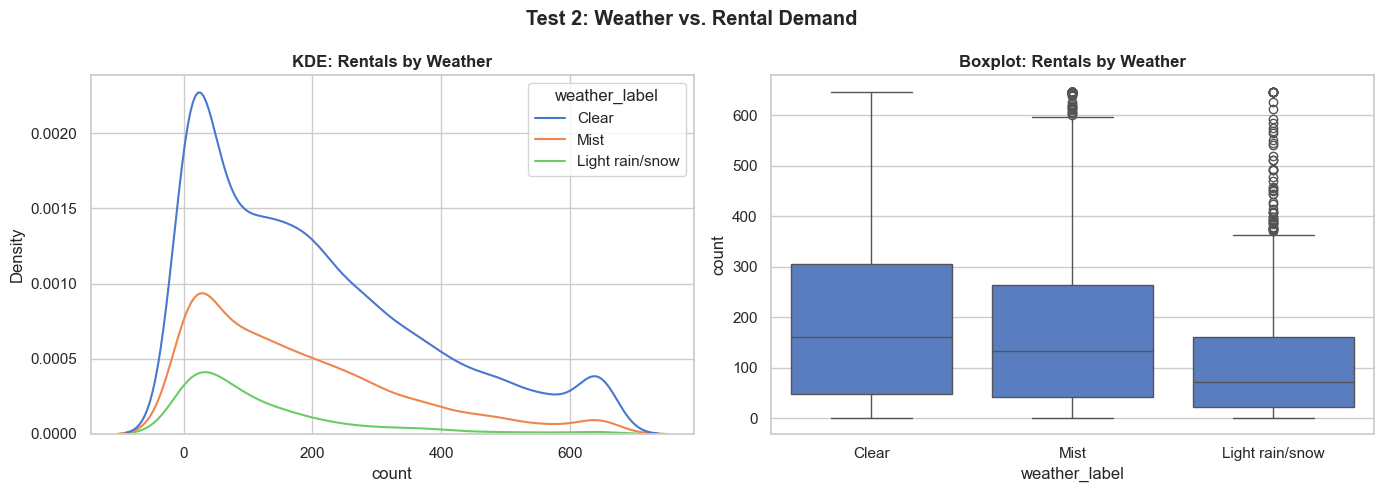

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order_w = [label for label in ['Clear', 'Mist', 'Light rain/snow', 'Heavy rain'] if label in df_clean['weather_label'].unique()]

sns.kdeplot(data=df_clean, x='count', hue='weather_label', ax=axes[0])
axes[0].set_title('KDE: Rentals by Weather', fontweight='bold')

sns.boxplot(data=df_clean, x='weather_label', y='count', order=order_w, ax=axes[1])
axes[1].set_title('Boxplot: Rentals by Weather', fontweight='bold')

plt.suptitle('Test 2: Weather vs. Rental Demand', fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretation:** <br> 
> -> The Kruskal-Wallis test found a <u>statistically significant difference</u> in bike rental demand across weather conditions ($p < 0.001 \leq \alpha = 0.05$). Therefore, the null hypothesis ($H_0$) that rental distributions are the same across weather categories is rejected. The estimated effect size ($\eta ^ 2 = 0.0187$) indicates that weather has a <u>small</u> practical effect on overall rental demand. <br>
> -> The post-hoc Dunn's test with Bonferroni correction shows that all pairwise comparisons are statistically significant. Rental distributions differ between clear weather, mist/cloudy conditions, and light rain/snow. The mean rank values follow a consistent pattern: Clear > Mist > Light rain/snow, indicating that rental demand gradually decreases as weather conditions worsen. <br>
> -> The KDE curves and boxplots support these results. Rentals during clear weather show the highest distribution of counts and the largest upper range, while mist conditions exhibit slightly lower demand. Light rain or snow shows the lowest median and a noticeably compressed distribution, indicating reduced rental activity. Although some overlap between distributions remains, the overall shift toward lower rental counts under worsening weather conditions is clearly visible. <br>
> -> These statistical findings confirm the exploratory patterns observed earlier in *Section 7.2*, where average rentals were shown to decline as weather conditions worsen. Overall, the results are consistent with the expectation that unfavorable weather discourages cycling, leading to lower demand for bike rentals.


***

### Test 3 - Does Season affect bike rental demand?

**Prior belief:** <br>
Seasonal conditions are expected to influence bike rental demand. Warmer seasons such as Summer and Fall generally provide more favorable conditions for outdoor activities and cycling, which may lead to higher rental counts. In contrast, colder seasons such as Winter and early Spring may discourage bike usage due to lower temperatures and less comfortable riding conditions. As a result, rental demand is expected to vary across seasons, with higher usage during warmer periods. However, whether these observed differences in rental levels represent statistically significant differences in the full rental distribution requires formal statistical testing. <br>

$H_0$: The distribution of bike rental is the same across all four seasons. <br>
$H_1$: At least one season has a different distribution of bike rentals.

**Significance level: $\alpha = 0.05$**

In [22]:
season_labels = ['Spring', 'Summer', 'Fall', 'Winter']
season_groups = []
for s in season_labels:
    group = df_clean[df_clean['season'] == s]['count']
    season_groups.append(group)
    print(f'{s: <6} -> n = {len(group): >3}, median = {group.median():.1f}, mean = {group.mean():.1f}')
print()

print('Step 1 -> Normality check (Shapiro-Wilk per season/group):')
for label, group in zip(season_labels, season_groups):
    _, p = shapiro(group.sample(min(500, len(group)), random_state=42))    
    print(f" - {label: <15}: p = {p:.4e} => {'Not normal' if p < ALPHA else 'Normal'}")
print()

print("Step 2 -> Variance homogeneity (Levene's test):")
lev_statistic, p_lev = levene(*season_groups)
print(f' - Levene: statistic = {lev_statistic:.4f}, p = {p_lev:.4e}')
print(f" - Variances {'Not' if p_lev < ALPHA else ''} equal")
print()

print('Step 3 -> Kruskal-Wallis test:')
kw_statistic, p_kw = kruskal(*season_groups)
print(f' - H = {kw_statistic:.4f}, p = {p_kw:.4e}')
print()

print('Step 4 -> Effect size:', end='')
n_total = sum(len(g) for g in season_groups)
eta2 = kruskal_eta_squared(kw_statistic, n_total, len(season_groups))
e_label = effect_label(eta2)
print(f' \u03B7\u00B2 = {eta2:.4f} ({e_label})')
print()

print('--- Results ---')
if p_kw < ALPHA:
    print(f' - p = {p_kw:.4e} < \u03B1 = {ALPHA} -> REJECTS H\u2080')
else:
    print(f' - p = {p_kw:.4e} >= \u03B1 = {ALPHA} -> FAILS TO REJECT H\u2080')

Spring -> n = 2686, median = 78.0, mean = 116.0
Summer -> n = 2733, median = 172.0, mean = 212.2
Fall   -> n = 2733, median = 195.0, mean = 229.2
Winter -> n = 2734, median = 161.0, mean = 196.2

Step 1 -> Normality check (Shapiro-Wilk per season/group):
 - Spring         : p = 1.2137e-20 => Not normal
 - Summer         : p = 4.7121e-18 => Not normal
 - Fall           : p = 3.2878e-15 => Not normal
 - Winter         : p = 1.5973e-17 => Not normal

Step 2 -> Variance homogeneity (Levene's test):
 - Levene: statistic = 199.5120, p = 5.7233e-126
 - Variances Not equal

Step 3 -> Kruskal-Wallis test:
 - H = 699.2818, p = 3.0046e-151

Step 4 -> Effect size: η² = 0.0640 (medium)

--- Results ---
 - p = 3.0046e-151 < α = 0.05 -> REJECTS H₀


In [23]:
n_comparisons = len(list(combinations(range(4), 2)))
print(f"Step 5 -> Post-hoc Dunn's test ({n_comparisons} comparisons, Bonferroni-corrected)")
print()

dunn_season = dunns_test_manual(season_groups, season_labels, alpha=ALPHA)
print(dunn_season.to_string(index=False))

Step 5 -> Post-hoc Dunn's test (6 comparisons, Bonferroni-corrected)

Group A Group B  Mean Rank A  Mean Rank B  Z-statistic p-value (raw) p-value (Bonferroni) Significant?
Spring   Summer       4093.5       5830.2      -20.340    0.0000e+00           0.0000e+00          Yes
Spring     Fall       4093.5       6182.3      -24.463    0.0000e+00           0.0000e+00          Yes
Spring   Winter       4093.5       5644.7      -18.168    0.0000e+00           0.0000e+00          Yes
Summer     Fall       5830.2       6182.3       -4.141    3.4573e-05           2.0744e-04          Yes
Summer   Winter       5830.2       5644.7        2.183    2.9034e-02           1.7421e-01           No
Fall     Winter       6182.3       5644.7        6.324    2.5415e-10           1.5249e-09          Yes


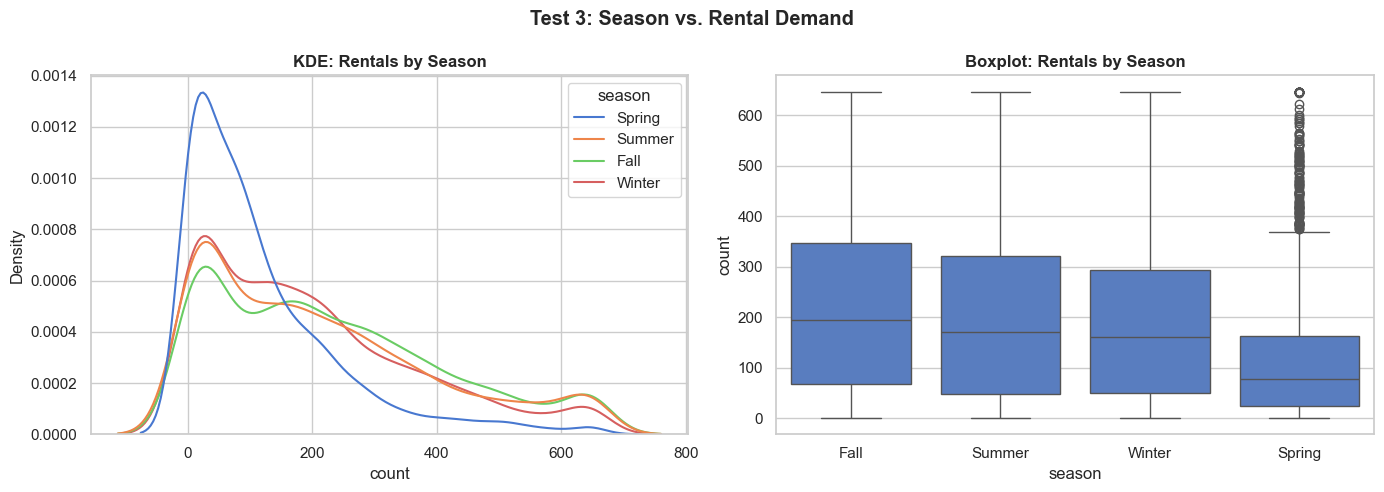

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df_clean, x='count', hue='season', ax=axes[0])
axes[0].set_title('KDE: Rentals by Season', fontweight='bold')

order_s = df_clean.groupby('season', observed=True)['count'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='season', y='count', order=order_s, ax=axes[1])
axes[1].set_title('Boxplot: Rentals by Season', fontweight='bold')

plt.suptitle('Test 3: Season vs. Rental Demand', fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretation:** <br>
> -> The Kruskal-Wallis test found a <u>statistically significant difference</u> in bike rental demand across seasons ($p < 0.001 \leq \alpha = 0.05$). Therefore, the null hypothesis ($H_0$) that rental distributions are the same across seasons is rejected. The estimated effect size ($\eta ^ 2 = 0.0640$) indicates that season has a <u>medium</u> practical effect on overall rental demand. <br>
> -> The post-hoc Dunn's test with Bonferroni correction shows that most pairwise comparisons are statistically significant. Spring differs significantly from Summer, Fall, and Winter, indicating substantially lower rental demand during this season. Fall also differs significantly from both Summer and Winter, reflecting the highest rental activity. However, the comparison between Summer and Winter is not statistically significant, suggesting that rental demand during these two seasons is relatively similar. <br>
> -> The KDE curves and boxplots support these results. Spring shows the lowest distribution of rental counts and a noticeably lower median, indicating reduced rental demand. Fall exhibits the highest median and the widest upper range of rentals, consistent with peak demand. Summer and Winter display partially overlapping distributions, explaining why their difference is not statistically significant despite Summer having slightly higher median rentals. <br>
> -> These statistical findings confirm the exploratory patterns observed earlier in *Section 7.2*, where Fall was shown to produce the highest average rentals while Spring exhibited substantially lower demand. Overall, the results suggest that seasonal conditions play an important role in shaping bike rental demand, with warmer seasons generally supporting higher levels of cycling activity.


***

### Test 4 - Are Weather and Season statistically dependent?

**Prior belief:** <br>
Seasonal patterns are expected to influence the distribution of weather conditions. For example, clear and warm weather may occur more frequently during Summer and Fall, while adverse conditions such as rain, snow, or mist may be more common in Winter and early Spring. Therefore, it is plausible that weather conditions are not evenly distributed across seasons. However, statistical testing is required to determine whether `season` and `weather` are significantly associated.

**Method rationale:** <br>
Both `season` and `weather` are categorical variables. The appropriate test for independence between two categorical variables is the Chi-Square Test of Independence, which compares observed cell frequencies to expected frequencies under the null hypothesis of independence. This test is also relevant for modeling considerations - if weather and season are statistically dependent, seasonal demand patterns may already partially reflect weather effects. As a result, including both variables simultaneosly in a regression model without accounting for their relationship could introduce multicollinearity, which can make coefficient estimates unstable and harder to interpret.

$H_0$: Weather and Season are statistically independent. <br>
$H_1$: Weather and Season are statistically dependent.

**Significance level: $\alpha = 0.05$**

In [53]:
 # rows = weather categories, columns = seasons, values = number of observation for each combination
contingency = pd.crosstab(df_clean['weather'], df_clean['season'])
print('Contingency table (Weather x Season) - observed counts:')
print(contingency)
print()

chi2_statistic, p_chi2, degrees_of_freedom, expected = chi2_contingency(contingency)
# Expected counts show what the table would look like if there was no relationship
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1))
print()
print(f'Chi-Square -> \u03C7\u00B2 = {chi2_statistic:.4f}, degrees of freedom = {degrees_of_freedom}, p = {p_chi2:.4e}')
print()

n_total = contingency.values.sum()
# Calculates Cramer's V using χ2, total observations, and table dimensions
v = cramers_v(chi2_statistic, n_total, contingency.shape[0], contingency.shape[1])
v_label = 'small' if v < 0.3 else 'medium' if v < 0.5 else 'large'
print(f"Effect size: (Cramer's V) = {v:.4f} ({v_label})")
print()

print('--- Results ---')
if p_chi2 < ALPHA:
    print(f' - p = {p_chi2:.4e} < \u03B1 = {ALPHA} -> REJECTS H\u2080')
else:
    print(f' - p = {p_chi2:.4e} >= \u03B1 = {ALPHA} -> FAILS TO REJECT H\u2080')

Contingency table (Weather x Season) - observed counts:
season   Spring  Summer  Fall  Winter
weather                              
1          1759    1801  1930    1702
2           715     708   604     807
3           211     224   199     225
4             1       0     0       0

season   Spring  Summer    Fall  Winter
weather                                
1        1774.5  1805.6  1805.6  1806.3
2         699.3   711.5   711.5   711.8
3         211.9   215.7   215.7   215.7
4           0.2     0.3     0.3     0.3

Chi-Square -> χ² = 49.1587, degrees of freedom = 9, p = 1.5499e-07

Effect size: (Cramer's V) = 0.0388 (small)

--- Results ---
 - p = 1.5499e-07 < α = 0.05 -> REJECTS H₀


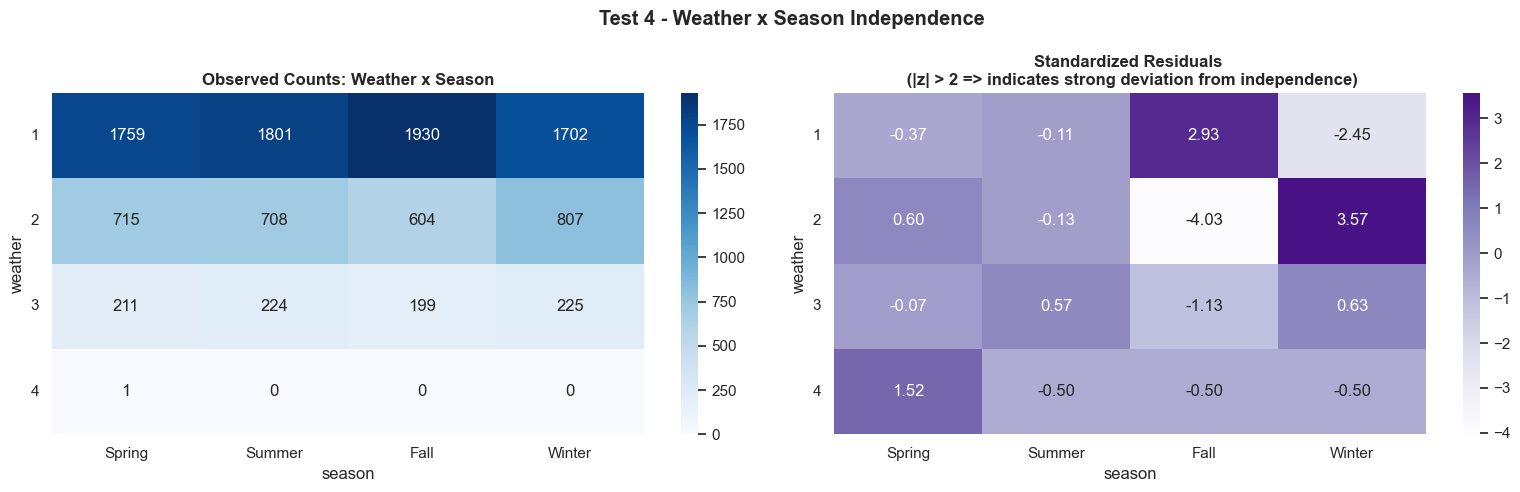

Cells with |z| > 2 (major contributors to χ²):
Weather = 1, Season = Fall: z = 2.93 (over-represented)
Weather = 2, Season = Fall: z = -4.03 (under-represented)
Weather = 1, Season = Winter: z = -2.45 (under-represented)
Weather = 2, Season = Winter: z = 3.57 (over-represented)


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Observed Counts: Weather x Season', fontweight='bold')
axes[0].tick_params(axis='y', rotation=360)

# residual = (observed - expected) / sqrt(expected) -> this measures how far each cell deviates from what would be expected
standardized_residuals = (contingency.values - expected) / (np.sqrt(expected))
# Converts the residual matrix into a DataFrame to keep rows/cols labels
std_res_df = pd.DataFrame(standardized_residuals, index=contingency.index, columns=contingency.columns)
sns.heatmap(std_res_df, annot=True, fmt='.2f', cmap='Purples', center=0, ax=axes[1])
axes[1].set_title('Standardized Residuals \n (|z| > 2 => indicates strong deviation from independence)', fontweight='bold')
axes[1].tick_params(axis='y', rotation=360)

plt.suptitle('Test 4 - Weather x Season Independence', fontweight='bold')
plt.tight_layout()
plt.show()

print('Cells with |z| > 2 (major contributors to \u03C7\u00B2):')
found = False
for season in std_res_df.columns:
    for weather_category in std_res_df.index:
        value = std_res_df.loc[weather_category, season]

        # Checks if the deviation from expectation is large
        if abs(value) > 2:
            direction = 'over-represented' if value > 0 else 'under-represented'
            print(f'Weather = {weather_category}, Season = {season}: z = {value:.2f} ({direction})')
            found = True

if not found:
    print('No cells exceed |z| > 2.')

> **Interpretation:** <br>
> -> The Chi-Square Test of independence found a <u>statistically significant association</u> between weather conditions and seasons ($\chi ^ 2 = 49.1587$, $p < 0.001 \leq \alpha = 0.05$). Therefore, the null hypothesis ($H_0$) that weather and season are statistically independent is rejected. However, the estimated effect size (Cramer's $V = 0.0388$) indicates that the strength of this association is <u>small</u>, suggesting that although the relationship is statistically detectable, its practical magnitude is limited. <br>
> -> The contingency table compares the observed frequencies of weather conditions across seasons with the expected frequencies that would occur if `weather` and `season` were statistically independent. The observed counts show that clear weather (category 1) dominates across all seasons, while mist/cloudy conditions (category 2) occur less frequently and adverse weather conditions (categories 3 and 4) are relatively rare. Comparing the observed counts with the expected frequencies reveals small deviations across seasons, suggesting that certain weather types may occur slightly more or less often than expected in particular seasons. <br>
> -> The heatmaps support these findings. The observed frequency table shows that clear weather dominates across all seasons but is particularly prominent in Fall. The standardized residual heatmap highlights the same pattern, with the largest positive and negative residuals appearing in the Fall and Winter columns. <br>
> -> To better understand which weather-season combinations contribute most to the detected dependence, standardized residuals were examined. Cells with $|z| > 2$ are typically considered meaningful contributors to the overall $\chi ^ 2$ statistic. The residual analysis indicates that clear weather (category 1) occurs more frequently than expected during Fall, while mist/cloudy conditions (category 2) occur less frequently than expected during Fall. In contrast, mist/cloudy conditions appear more often than expected during Winter, while clear weather occurs less frequently than expected in Winter. These deviations from expected frequencies are the primary contributors to the observed dependence between weather and season. <br>
> -> Overall, the results suggest that `season` and `weather` are not entirely independent, meaning that the distribution of weather conditions varies somewhat across seasons. However, the small effect size indicates that this relationship is relatively weak, implying that seasonal patterns only partially explain variations in weather conditions within the data.


***

## 9. Hypothesis Testing - Complete Summary

In [52]:
summary = pd.DataFrame({
    'Test': [
        'Working Day vs Rental Count',
        'Weather vs Rental Count',
        'Season vs Rental Count',
        'Weather ~ Season (Independence)'
    ],
    'Method': [
        'Kruskal-Wallis',
        'Kruskal-Wallis + Dunn post-hoc',
        'Kruskal-Wallis + Dunn post hoc',
        'Chi-Square + Standardized Residuals'
    ],
    'Why non-parametric?': [
        'count not normal (SW p < 0.001)',
        'count not normal (SW p < 0.001)',
        'count not normal (SW p < 0.001)',
        'Both variables categorical'
    ],
    'H\u2080 Rejected?': ['No', 'Yes', 'Yes', 'Yes'],
    'Effect Size': [
        '\u03B7\u00B2 (negligible)',
        '\u03B7\u00B2 (small)',
        '\u03B7\u00B2 (medium)',
        "Cramer's V (small)"
    ],
    'Post-hoc': [
        'N/A (2 groups)',
        "Dunn's + Bonferroni",
        "Dunn's + Bonferroni",
        'Standardized residuals'
    ]
})

print(summary.to_string(
    index=False,
    col_space={
        'Test': 40,
        'Method': 30,
        'Why non-parametric?': 40,
        'H\u2080 Rejected?': 5,
        'Effect Size': 5,
        'Post-hoc': 25
    },
    justify='center'
))
print()

print('Effect size ranking: season > weather >> working day')

                  Test                                  Method                         Why non-parametric?            H₀ Rejected?    Effect Size              Post-hoc        
        Working Day vs Rental Count                           Kruskal-Wallis     count not normal (SW p < 0.001)           No         η² (negligible)           N/A (2 groups) 
            Weather vs Rental Count           Kruskal-Wallis + Dunn post-hoc     count not normal (SW p < 0.001)          Yes              η² (small)      Dunn's + Bonferroni 
             Season vs Rental Count           Kruskal-Wallis + Dunn post hoc     count not normal (SW p < 0.001)          Yes             η² (medium)      Dunn's + Bonferroni 
    Weather ~ Season (Independence)      Chi-Square + Standardized Residuals          Both variables categorical          Yes      Cramer's V (small)   Standardized residuals 

Effect size ranking: weather > season >> working day


> **Interpretation:** <br>
> -> The statistical analysis identifies season and weather as the main drivers of bike rental demand, with season showing the strongest overall effect and weather contributing additional short-term variation. In contrast, the distinction between working and non-working days does not significantly affect total rental demand, suggesting that differences between user types balance out at the aggregate level. The analysis also shows that weather and season are statistically associated, meaning that seasonal patterns partially reflect underlying weather conditons. <br>
> -> These findings provide a clear statistical foundation for the operational and strategic recommendations presented in the next section.


***

## 10. Business Insights and Strategic Recommendations for Yulu

### Key Findings
1. **Season is the strongest driver of demand** (largest $\eta ^ 2$ effect size). <br>
Rental demand varies substantially across seasons, with Fall and Summer producing the highest activity and Spring the lowest. The <u>medium</u> effect size indicates that seasonal patterns play a meaningful role in shaping overall bike rental demand.
2. **Weather significantly influences demand, but with a smaller effect size.** <br>
Clear weather is associated with the highest rental activity, while mist, rain, and snow reduce demand. Although the effect is statistically significant, the magnitude is relatively <u>small</u> compared to seasonality, suggesting that weather primarily introduces short-term daily fluctuations rather than long-term structural changes in demand.
3. **Working day status does not significantly affect rental demand.** <br>
The analysis finds no statistically significant difference between working and non-working days in overall rental counts. This likely reflects the balance between registered commuter usage during weekdays and casual leisure usage during weekends, which results in similar total demand levels.
4. **Weather and Season are statistically associated.** <br>
The Chi-Squared test confirms that weather conditions vary somewhat across seasons, meaning the two variables are not completely independent.  However, the association is weak, suggesting that season only partially explains the distribution of weather conditions.
5. **Effect size hierarchy: season > weather >> working day.** <br>
This ranking highlights where the largest drivers of demand lie and helps prioritize which factors should receive the greatest attention in forecasting and operational planning.

### Strategic Recommendations for Yulu
1. **Adjust bike availability based on seasonal demand.** <br>
Increase the number of bikes deployed during higher-demand seasons, like Fall and Summer, and reduce or redistribute bikes during lower-demand periods to maintain efficient utilization.
2. **Use weather forecasts to guide daily operations.** <br>
Integrate weather forecast data into daily bike redistribution planning. Increase bike availability on clear-weather days when demand is higher, and schedule maintenance or redistribution during unfavorable weather conditions.
3. **Combine season and weather information in operational planning.** <br>
Since season and weather are statistically related, bike distribution decisions should consider both factors together. For example, ensure higher bike availability during clear days within high-demand seasons (Fall, Summer).
4. **Increase user engagement during low-demand seasons.** <br>
Implement targeted promotions, discounts, or marketing campaigns during low-demand periods (for example: Spring) to encourage additional bike rentals and reduce seasonal demand fluctuations. Increasing usage during off-peak months can help maintain more stable revenue throughout the year.
5. **Adjust bike distribution based on user behavior patterns.** <br>
Although total rental demand does not differ significantly between working and non-working days, user behavior varies throughout the week. On working days, demand peaks during morning and evening commuting hours, particularly near business districts and transit hubs. On weekends, usage shifts toward leisure and recreational areas. Yulu should therefore adjust bike distribution accordingly, ensuring higher bike availability near commuter corridors during weekdays and near parks, entertainment zones, and leisure destinations during weekends.


***

### References
* Chi-Squared - [Kaggle](https://www.kaggle.com/code/pythonafroz/t-test-anova-chi-squared-f-test-z-test)
* Cramer's V - [MetricGate](https://metricgate.com/docs/cramers-v/)
* Density plots interpretation - [YouTube](https://www.youtube.com/watch?v=CbqoxkkJyzY)
* Hypothesis Testing - [YouTube](https://www.youtube.com/watch?v=5cZE2mhPvSU)
* Kruskal-Wallis - [numiqo](https://numiqo.com/tutorial/kruskal-wallis-test)
* Shapiro-Wilk 1 - [Medium](https://medium.com/@data-overload/the-shapiro-wilk-test-a-guide-to-normality-testing-d730e820d1a8)
* Shapiro-Wilk 2 - [Statistics Kingdom](https://www.statskingdom.com/doc_shapiro_wilk.html)
* Yulu Bike Sharing Dataset - [Kaggle](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data)
* Yulu Data Analysis project1 - [Kaggle](https://www.kaggle.com/code/tanmayadhikary/yulu-data-analysis)
* Yulu Data Analysis project2 - [Kaggle](https://www.kaggle.com/code/roggerr/yulu-eda-and-hypthesis-testing-in-detail/notebook)